<a href="https://colab.research.google.com/github/mandar-solanki/exercises/blob/main/2604-Applied-Data-Modelling-using-Gradio/0430%20Hiring%20Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 2026-04-29 Thursday Session
Contents discussed -
1) Linear Regression
2) Appraisal Analysis Gradio App.ipynb


Outcomes -
1) Create Hiring prediction model using Gradio with 3 tabs - EDA, Model Evaluation, Prediction


In [1]:
filepath = r'https://raw.githubusercontent.com/suyashi29/python-su/refs/heads/master/Applied%20Data%20Modelling%20using%20Gradio/hiredata.csv'


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score


In [9]:
#Load Data
df = pd.read_csv(filepath)
print(df.head())
print()
print(df.isnull().sum())
print()
print(df.describe())
print()
print(df.corr(numeric_only=True))


   YearsExperience EducationLevel  SkillsScore  CertificationCount  Hired
0                6    High School           88                   0      0
1                3    High School           50                   3      0
2               12            PhD           78                   2      1
3               14  Post-Graduate           63                   3      1
4               10    High School           99                   3      1

YearsExperience       0
EducationLevel        0
SkillsScore           0
CertificationCount    0
Hired                 0
dtype: int64

       YearsExperience  SkillsScore  CertificationCount        Hired
count      1200.000000  1200.000000         1200.000000  1200.000000
mean          6.952500    69.496667            3.456667     0.412500
std           4.378686    17.345192            2.267688     0.492489
min           0.000000    40.000000            0.000000     0.000000
25%           3.000000    55.000000            2.000000     0.000000
50%    

In [10]:
# EDA functions
def eda_summary():
    return df.describe().to_string()

def eda_corr():
    plt.figure()
    sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='rocket_r')
    plt.title('Correlation Plot')
    return plt


In [11]:
eda_summary()

'       YearsExperience  SkillsScore  CertificationCount        Hired\ncount      1200.000000  1200.000000         1200.000000  1200.000000\nmean          6.952500    69.496667            3.456667     0.412500\nstd           4.378686    17.345192            2.267688     0.492489\nmin           0.000000    40.000000            0.000000     0.000000\n25%           3.000000    55.000000            2.000000     0.000000\n50%           7.000000    69.000000            3.000000     0.000000\n75%          11.000000    84.000000            5.000000     1.000000\nmax          14.000000    99.000000            7.000000     1.000000'

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

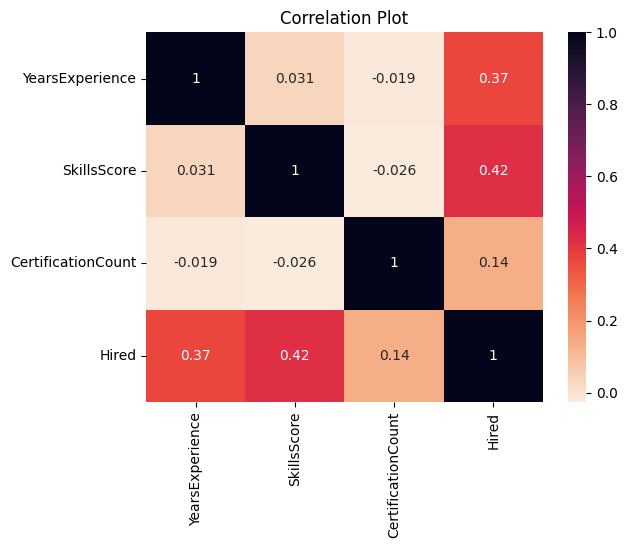

In [12]:
eda_corr()

In [16]:
# Data Preparation

X = df[df.columns[:-1]]
y = df[df.columns[-1]]

cat_cols = ['EducationLevel']
num_cols = ['YearsExperience', 'SkillsScore', 'CertificationCount']

preproccesor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

model = Pipeline([
    ('preprocessor', preproccesor),
    ('regressor', LogisticRegression())
])

# Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=1)



In [26]:
# Train
model.fit(X_train, y_train)

# Predictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, test_pred)
precision = precision_score(y_test, test_pred)
recall = recall_score(y_test, test_pred)
cnf_matrix = confusion_matrix(y_test, test_pred)

def model_evaluation():
    result = f'Accuracy : {accuracy:.3f}\n'
    result += f'Precision : {precision:.3f}\n'
    result += f'Recall : {recall:.3f}\n'
    result += f'Confusion Matrix : \n{cnf_matrix}'
    return result


In [25]:
model_evaluation()

'Accuracy : 0.783\nPrecision : 0.772\nRecall : 0.691\nConfusion Matrix : [[177  31]\n [ 47 105]]'

In [45]:
# Predict function

def predict(EducationLevel, YearsExperience, SkillsScore, CertificationCount):
    input_df = pd.DataFrame({
        'EducationLevel': [EducationLevel],
        'YearsExperience': [int(YearsExperience)],
        'SkillsScore': [int(SkillsScore)],
        'CertificationCount': [int(CertificationCount)]
    })
    pred = model.predict(input_df)[0]
    if pred >= 0.5:
        return 'Hired'
    return 'Not Hired'


In [48]:
predict('Diploma', 5, 2, 3)


'Not Hired'

In [47]:
# Gradio UI

with gr.Blocks(title='Hiring Model') as app:
    gr.Markdown('## Hiring Model Predictor')

    # EDA
    with gr.Tab('EDA'):
        gr.Markdown('### Dataset Overview')
        gr.Dataframe(df.head())
        with gr.Row():
            with gr.Column():
                but_summary = gr.Button('Summary Stats')
                out_summary = gr.TextArea()
                but_summary.click(fn=eda_summary, outputs=out_summary)
            with gr.Column():
                but_corr = gr.Button('Correlation Matrix')
                out_corr = gr.Plot()
                but_corr.click(fn=eda_corr, outputs=out_corr)

    # Model Performance
    with gr.Tab('Model Evaluation'):
        gr.Markdown('### Regression Metrics')
        but_model_metrics = gr.Button('Show Model Metrics')
        out_model_metrics = gr.TextArea()
        but_model_metrics.click(fn=model_evaluation, outputs=out_model_metrics)

    # Prediction
    with gr.Tab('Model Prediction'):
        gr.Markdown('### Predict Hiring')
        with gr.Row():
            yrs_exp = gr.Number(label = 'Experience')
            edu_level = gr.Dropdown(choices=sorted(df['EducationLevel'].unique().tolist()), label='Education Level')
        with gr.Row():
            skill_score = gr.Number(label = 'Skills Score')
            cert_cnt = gr.Number(label='Number of Certifications')
        with gr.Row():
            but_pred = gr.Button('Predict')
            out_pred = gr.Textbox()
            but_pred.click(
                fn=predict,
                inputs=[edu_level, yrs_exp, skill_score, cert_cnt],
                outputs=out_pred
            )



In [49]:
app.launch(share=False, debug=True)


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

Keyboard interruption in main thread... closing server.
